####  Title: Linear regression by using Deep Neural network: Implement Boston housing price prediction problem by Linear regression using Deep Neural network. Use Boston House price prediction dataset.

#### Name: Sankalp S. Indish

#### Roll No.: BEB75

#### Important Note on the Dataset:
* The Boston Housing dataset was recently removed from scikit-learn due to ethical concerns regarding racial bias in the data. However, for academic practicals, it is often still accessible via tensorflow.keras.datasets or specific URLs. I will use the Keras method below as it is the most stable for Colab.

#### Step 1: Import Libraries and Load Data
We will use TensorFlow/Keras for the model and Scikit-Learn for preprocessing.

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load the dataset directly from Keras
# This dataset contains 13 features (X) and the target price (y)
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.boston_housing.load_data()

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
Training data shape: (404, 13)
Test data shape: (102, 13)


#### Step 2: Data Preprocessing (Normalization)
Neural networks converge much faster and perform better when the input data is scaled (normalized). We will normalize the data so that it has a mean of 0 and a standard deviation of 1.

In [2]:
# Create the scaler
scaler = StandardScaler()

# Fit only on training data to prevent data leakage
scaler.fit(X_train)

# Transform both training and test data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify the first sample
print("First sample (normalized):", X_train_scaled[0])

First sample (normalized): [-0.27224633 -0.48361547 -0.43576161 -0.25683275 -0.1652266  -0.1764426
  0.81306188  0.1166983  -0.62624905 -0.59517003  1.14850044  0.44807713
  0.8252202 ]


#### Step 3: Build the Deep Neural Network Model
- To solve this regression problem using a Deep Neural Network, we will add hidden layers.

- Input Layer: Matches the number of features (13).

- Hidden Layers: Use 'relu' activation to capture non-linear patterns.

- Output Layer: 1 unit with 'linear' activation (or no activation). This is crucial for regression because we want to predict a continuous real number (the price).

In [3]:
model = Sequential()

# Input Layer + First Hidden Layer
# 64 neurons, ReLU activation, input_shape is 13 features
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

# Second Hidden Layer
model.add(Dense(32, activation='relu'))

# Output Layer
# 1 neuron for the single price value.
# Activation is 'linear' (default) because this is a regression problem.
model.add(Dense(1))

# Compile the model
# Loss function: Mean Squared Error (MSE) is standard for regression
# Optimizer: Adam is a standard, efficient optimizer
# Metrics: Mean Absolute Error (MAE) explains how far off we are in dollars
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

#### Step 4: Train the Model
We will train the model for 100 epochs. We use validation_split to monitor performance on unseen data during training.

In [4]:
history = model.fit(X_train_scaled, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 525.2753 - mae: 21.3525 - val_loss: 595.8068 - val_mae: 22.6162
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 531.3636 - mae: 21.0597 - val_loss: 552.9687 - val_mae: 21.6853
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 495.4727 - mae: 20.0811 - val_loss: 499.7518 - val_mae: 20.4793
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 390.6249 - mae: 17.9435 - val_loss: 435.6399 - val_mae: 18.9748
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 371.0034 - mae: 17.0701 - val_loss: 361.2296 - val_mae: 17.0272
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 295.4570 - mae: 14.9835 - val_loss: 280.5740 - val_mae: 14.6073
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 206.5495 - mae: 12.2640 - val_loss: 205.7577 - val_mae: 11.8970
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 146.5007 - mae: 9.8104 - val_loss: 148.2658 - val_mae: 9.5934
Epoch 9/100


#### Step 5: Evaluate the Model
Now we check how well the model performs on the test set that it has never seen before.

In [5]:
# Evaluate on test data
test_loss, test_mae = model.evaluate(X_test_scaled, y_test)

print(f"\nTest Mean Absolute Error: {test_mae:.2f}")
print(f"This means our predictions are off by approx ${test_mae * 1000} on average.")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 21.5624 - mae: 2.9888

Test Mean Absolute Error: 3.21
This means our predictions are off by approx $3211.878538131714 on average.


- Note: The target values in this dataset are in "thousands of dollars". So an MAE of 3.5 means the prediction is off by $3,500.

#### Step 6: Visualization
It is best practice to plot the training history to see if the model is learning or overfitting.

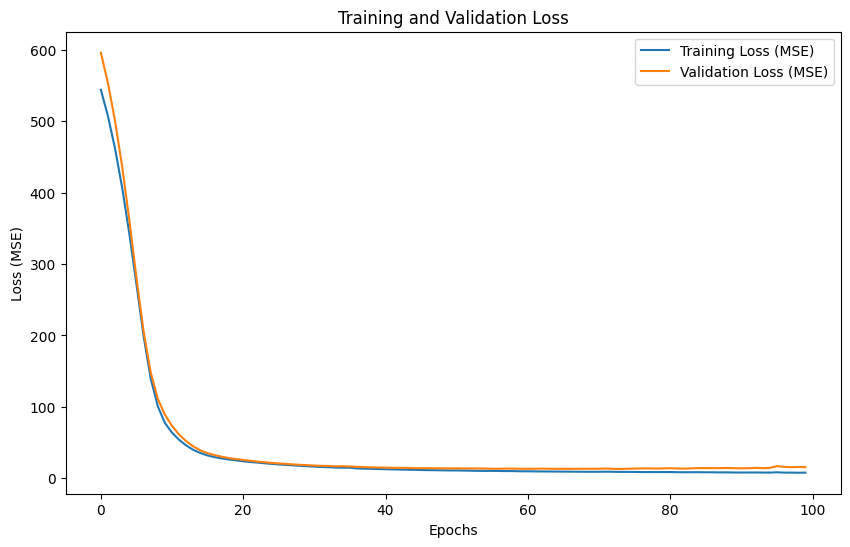

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

#### Summary:
- Why use StandardScaler? Boston housing features have different units (e.g., crime rate vs. tax rate). Neural networks struggle if inputs vary wildly in scale. Normalization fixes this.

- Why ReLU in hidden layers? To introduce non-linearity, allowing the model to learn complex patterns.

- Why Linear in output layer? Because we need to predict a specific number (price), not a probability (0 to 1).

- Loss Function: We used MSE (Mean Squared Error), which penalizes large errors heavily, standard for regression.